<a href="https://colab.research.google.com/github/AxisAngeles/Smart_Data_DS_AI/blob/main/Laboratorio_PCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#########################################################################
########------ Ciencia de Datos e IA Generativa con Python ------########
#########################################################################
# Capacitador: Julio César Bernal Fernández
# email: juliobf08@gmail.com
# Tema : Laboratorio Componentes Principales (PCA)
# versión: 1.0
#########################################################################

#Laboratorio de PCA


In [1]:
import numpy as np
from sklearn.decomposition import PCA
from sklearn.datasets import load_breast_cancer

Los datos utilizados en este ejemplo son los datos de cáncer de mama proporcionados por scikit-learn. Se trata de un conjunto de datos clásicos utilizados para el aprendizaje automático y la investigación en el campo de la detección temprana del cáncer.

Este conjunto de datos contiene información de 569 pacientes con cáncer de mama y 30 características diferentes relacionadas con las imágenes de las masas mamarias. Los pacientes son clasificados como benignos (no cancerosos) o malignos (cancerosos).


Los datos están en un formato de una matriz de numpy, donde cada fila representa un paciente y cada columna representa una característica de la masa mamaria. El objetivo es entender la relación entre las características y la clasificación del paciente (benigno o maligno).

In [2]:
import pandas as pd

data_names = {
    'Nombre de la característica': ['radius', 'texture', 'perimeter', 'area', 'smoothness', 'compactness', 'concavity', 'concave points', 'symmetry', 'fractal dimension', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal dimension_worst'],
    'Significado': ['Radio promedio de las células', 'Textura promedio de las células', 'Perímetro promedio de las células', 'Área promedio de las células', 'Suavidad promedio de las fronteras de las células', 'Compactación promedio de las células', 'Concavidad promedio de las células', 'Número promedio de puntos concavos en las células', 'Simetría promedio de las células', 'Dimensión fractal promedio de las células', 'Error estándar del radio', 'Error estándar de la textura', 'Error estándar del perímetro', 'Error estándar del área', 'Error estándar de la suavidad de las fronteras de las células', 'Error estándar de la compactación de las células', 'Error estándar de la concavidad de las células', 'Error estándar del número de puntos concavos en las células', 'Error estándar de la simetría de las células', 'Error estándar de la dimensión fractal de las células', 'Radio del punto más anormal', 'Textura del punto más anormal', 'Perímetro del punto más anormal', 'Área del punto más anormal', 'Suavidad de las fronteras del punto más anormal', 'Compactación del punto más anormal', 'Concavidad del punto más anormal', 'Número de puntos concavos del punto más anormal', 'Simetría del punto más anormal', 'Dimensión fractal del punto más anormal']
}
df_names = pd.DataFrame(data_names)
display(df_names)
#df.style.set_properties(**{'text-align': 'center'})

,Nombre de la característica,Significado
0,radius,Radio promedio de las células
1,texture,Textura promedio de las células
2,perimeter,Perímetro promedio de las células
3,area,Área promedio de las células
4,smoothness,Suavidad promedio de las fronteras de las células
5,compactness,Compactación promedio de las células
6,concavity,Concavidad promedio de las células
7,concave points,Número promedio de puntos concavos en las células
8,symmetry,Simetría promedio de las células
9,fractal dimension,Dimensión fractal promedio de las células


In [3]:
# El dataset importado es un JSON.
load_breast_cancer()

{'data': array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
         1.189e-01],
        [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
         8.902e-02],
        [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
         8.758e-02],
        ...,
        [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
         7.820e-02],
        [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
         1.240e-01],
        [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
         7.039e-02]]),
 'target': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
        0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
        1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
        1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
        1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0

In [4]:
# Cargando los datos
data = load_breast_cancer()
X = data.data
y = data.target

In [5]:
print(X)

[[1.799e+01 1.038e+01 1.228e+02 ... 2.654e-01 4.601e-01 1.189e-01]
 [2.057e+01 1.777e+01 1.329e+02 ... 1.860e-01 2.750e-01 8.902e-02]
 [1.969e+01 2.125e+01 1.300e+02 ... 2.430e-01 3.613e-01 8.758e-02]
 ...
 [1.660e+01 2.808e+01 1.083e+02 ... 1.418e-01 2.218e-01 7.820e-02]
 [2.060e+01 2.933e+01 1.401e+02 ... 2.650e-01 4.087e-01 1.240e-01]
 [7.760e+00 2.454e+01 4.792e+01 ... 0.000e+00 2.871e-01 7.039e-02]]


In [6]:
print(y)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 1 0 0 0 0 0 0 0 0 1 0 1 1 1 1 1 0 0 1 0 0 1 1 1 1 0 1 0 0 1 1 1 1 0 1 0 0
 1 0 1 0 0 1 1 1 0 0 1 0 0 0 1 1 1 0 1 1 0 0 1 1 1 0 0 1 1 1 1 0 1 1 0 1 1
 1 1 1 1 1 1 0 0 0 1 0 0 1 1 1 0 0 1 0 1 0 0 1 0 0 1 1 0 1 1 0 1 1 1 1 0 1
 1 1 1 1 1 1 1 1 0 1 1 1 1 0 0 1 0 1 1 0 0 1 1 0 0 1 1 1 1 0 1 1 0 0 0 1 0
 1 0 1 1 1 0 1 1 0 0 1 0 0 0 0 1 0 0 0 1 0 1 0 1 1 0 1 0 0 0 0 1 1 0 0 1 1
 1 0 1 1 1 1 1 0 0 1 1 0 1 1 0 0 1 0 1 1 1 1 0 1 1 1 1 1 0 1 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 1 1 1 1 1 1 0 1 0 1 1 0 1 1 0 1 0 0 1 1 1 1 1 1 1 1 1 1 1 1
 1 0 1 1 0 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 0 1 0 1 1 1 1 0 0 0 1 1
 1 1 0 1 0 1 0 1 1 1 0 1 1 1 1 1 1 1 0 0 0 1 1 1 1 1 1 1 1 1 1 1 0 0 1 0 0
 0 1 0 0 1 1 1 1 1 0 1 1 1 1 1 0 1 1 1 0 1 1 0 0 1 1 1 1 1 1 0 1 1 1 1 1 1
 1 0 1 1 1 1 1 0 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 0 1 0 0 1 0 1 1 1 1 1 0 1 1
 0 1 0 1 1 0 1 0 1 1 1 1 1 1 1 1 0 0 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 0 1
 1 1 1 1 1 1 0 1 0 1 1 0 

In [8]:
pd.DataFrame(X).info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       569 non-null    float64
 1   1       569 non-null    float64
 2   2       569 non-null    float64
 3   3       569 non-null    float64
 4   4       569 non-null    float64
 5   5       569 non-null    float64
 6   6       569 non-null    float64
 7   7       569 non-null    float64
 8   8       569 non-null    float64
 9   9       569 non-null    float64
 10  10      569 non-null    float64
 11  11      569 non-null    float64
 12  12      569 non-null    float64
 13  13      569 non-null    float64
 14  14      569 non-null    float64
 15  15      569 non-null    float64
 16  16      569 non-null    float64
 17  17      569 non-null    float64
 18  18      569 non-null    float64
 19  19      569 non-null    float64
 20  20      569 non-null    float64
 21  21      569 non-null    float64
 22  22

In [9]:
# Instanciando y ajustando el modelo
pca = PCA(n_components=2) # defino un modelo de 2 componentes
pca.fit(X) # Método fit con el set de datos.

PCA(n_components=2)

In [11]:
# Transformando los datos
X_pca = pca.transform(X) # Método para transformar el set de datos, utilizando el modelo previamente definido.

In [12]:
# Imprimiendo los componentes principales
print(pca.components_)

[[ 5.08623202e-03  2.19657026e-03  3.50763298e-02  5.16826469e-01
   4.23694535e-06  4.05260047e-05  8.19399539e-05  4.77807775e-05
   7.07804332e-06 -2.62155251e-06  3.13742507e-04 -6.50984008e-05
   2.23634150e-03  5.57271669e-02 -8.05646029e-07  5.51918197e-06
   8.87094462e-06  3.27915009e-06 -1.24101836e-06 -8.54530832e-08
   7.15473257e-03  3.06736622e-03  4.94576447e-02  8.52063392e-01
   6.42005481e-06  1.01275937e-04  1.68928625e-04  7.36658178e-05
   1.78986262e-05  1.61356159e-06]
 [ 9.28705650e-03 -2.88160658e-03  6.27480827e-02  8.51823720e-01
  -1.48194356e-05 -2.68862249e-06  7.51419574e-05  4.63501038e-05
  -2.52430431e-05 -1.61197148e-05 -5.38692831e-05  3.48370414e-04
   8.19640791e-04  7.51112451e-03  1.49438131e-06  1.27357957e-05
   2.86921009e-05  9.36007477e-06  1.22647432e-05  2.89683790e-07
  -5.68673345e-04 -1.32152605e-02 -1.85961117e-04 -5.19742358e-01
  -7.68565692e-05 -2.56104144e-04 -1.75471479e-04 -3.05051743e-05
  -1.57042845e-04 -5.53071662e-05]]


In [13]:
# imprimiendo la proporción de varianza explicada por cada componente principal
print(pca.explained_variance_ratio_)

[0.98204467 0.01617649]


In [ ]:
0.98204467+0.01617649

### **Conclusión sobre el modelo PCA**
---
1. El modelo se definió con 2 componentes.
2. Con el método "explaide_variance_ratio_" obtenemos el valor explicativo del modelo que definimos. En este caso, **98%**.
---

**Esto quiere decir que un modelo con 2 componentes principales funciona perfectamente**

In [14]:
import matplotlib.pyplot as plt

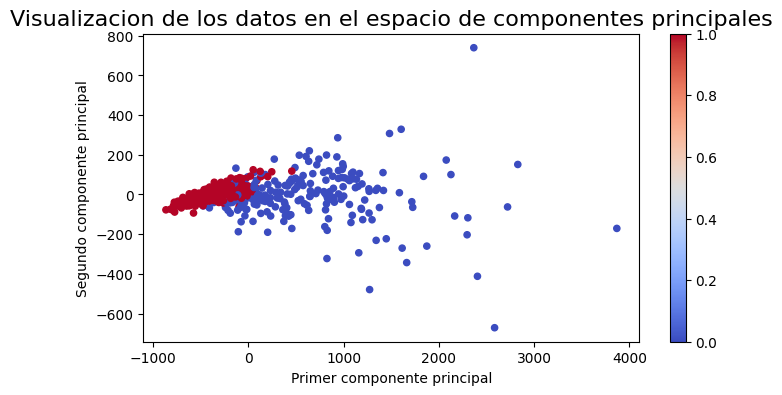

In [15]:
plt.figure(figsize=(8,4))
plt.scatter(X_pca[: , 0 ] ,  X_pca[: , 1 ]  , c=y , cmap ='coolwarm' , s=20)
plt.xlabel("Primer componente principal")
plt.ylabel("Segundo componente principal")
plt.title("Visualizacion de los datos en el espacio de componentes principales" , fontsize=16)
plt.colorbar()
plt.show()

In [16]:
# obteniendo los coeficientes de los componentes principales
coef = pca.components_
print(coef)

[[ 5.08623202e-03  2.19657026e-03  3.50763298e-02  5.16826469e-01
   4.23694535e-06  4.05260047e-05  8.19399539e-05  4.77807775e-05
   7.07804332e-06 -2.62155251e-06  3.13742507e-04 -6.50984008e-05
   2.23634150e-03  5.57271669e-02 -8.05646029e-07  5.51918197e-06
   8.87094462e-06  3.27915009e-06 -1.24101836e-06 -8.54530832e-08
   7.15473257e-03  3.06736622e-03  4.94576447e-02  8.52063392e-01
   6.42005481e-06  1.01275937e-04  1.68928625e-04  7.36658178e-05
   1.78986262e-05  1.61356159e-06]
 [ 9.28705650e-03 -2.88160658e-03  6.27480827e-02  8.51823720e-01
  -1.48194356e-05 -2.68862249e-06  7.51419574e-05  4.63501038e-05
  -2.52430431e-05 -1.61197148e-05 -5.38692831e-05  3.48370414e-04
   8.19640791e-04  7.51112451e-03  1.49438131e-06  1.27357957e-05
   2.86921009e-05  9.36007477e-06  1.22647432e-05  2.89683790e-07
  -5.68673345e-04 -1.32152605e-02 -1.85961117e-04 -5.19742358e-01
  -7.68565692e-05 -2.56104144e-04 -1.75471479e-04 -3.05051743e-05
  -1.57042845e-04 -5.53071662e-05]]


In [17]:
print(coef[0,23])
print(coef[0,3])
print(coef[0,13])

0.852063391798146
0.5168264687224582
0.05572716691107043


In [18]:
print(coef[1,3])
print(coef[1,23])
print(coef[1,2])

0.8518237204834195
-0.5197423583172234
0.0627480827489297


In [19]:
# ordenando los coeficientes de cada componente principal
sorted_coef_indices = np.argsort(abs(coef), axis=1)
print(sorted_coef_indices)

[[19 14 18 29  9 17  4 15 24  8 16 28  5  7 11 27  6 25 26 10  1 12 21  0
  20  2 22 13  3 23]
 [19 14  5 17 18 15  4  9  8 16 27  7 10 29  6 24 28 26 22 25 11 20 12  1
  13  0 21  2 23  3]]


In [20]:
sorted_coef_indices[0 , -3:]

array([13,  3, 23])

In [21]:
np.sign( coef )

array([[ 1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1., -1.,  1., -1.,  1.,
         1., -1.,  1.,  1.,  1., -1., -1.,  1.,  1.,  1.,  1.,  1.,  1.,
         1.,  1.,  1.,  1.],
       [ 1., -1.,  1.,  1., -1., -1.,  1.,  1., -1., -1., -1.,  1.,  1.,
         1.,  1.,  1.,  1.,  1.,  1.,  1., -1., -1., -1., -1., -1., -1.,
        -1., -1., -1., -1.]])

In [22]:
n_top_features = 3 # Numero de caracteristicas que vamos a mostrar
n_components = 2 # Numero de componentes que hemos utilizado
feature_names = data_names['Nombre de la característica'] # Nombres
feature_meaning =  data_names['Significado'] # El sginificado
signs = np.sign( coef )

#Imprimier las caracteristicas mas importantes

for i in range(n_components):
  print(f"Caracteristicas mas importantes para el componente {i+1}")
  for j in sorted_coef_indices[i , -n_top_features:]:
    print(f"{feature_names[j] , feature_meaning[j]  , signs[i][j] }" )
  print()

Caracteristicas mas importantes para el componente 1
('area_se', 'Error estándar del área', np.float64(1.0))
('area', 'Área promedio de las células', np.float64(1.0))
('area_worst', 'Área del punto más anormal', np.float64(1.0))

Caracteristicas mas importantes para el componente 2
('perimeter', 'Perímetro promedio de las células', np.float64(1.0))
('area_worst', 'Área del punto más anormal', np.float64(-1.0))
('area', 'Área promedio de las células', np.float64(1.0))



### Empezando por el gráfico
_Varianza Acumulada_

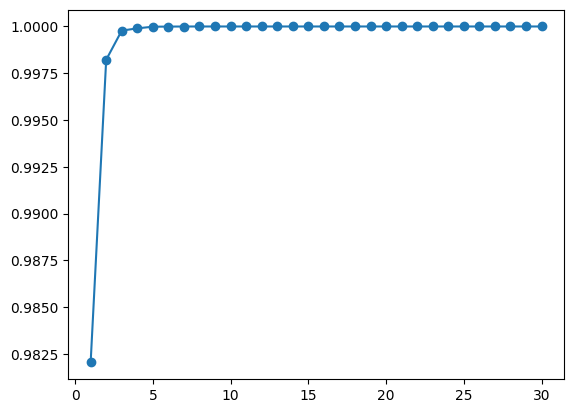

In [27]:
#Aplicar PCA con diferentes valores del numero de compontes
pca = PCA()
X_PCA = pca.fit_transform(X)

#Grafica de la proporcion de varianza
#pca.explained_variance_ratio_

plt.plot(range(1 , X.shape[1]+1) , np.cumsum(pca.explained_variance_ratio_),marker='o')



In [28]:
print(pca.explained_variance_ratio_ , pca.explained_variance_ratio_.shape)

[9.82044672e-01 1.61764899e-02 1.55751075e-03 1.20931964e-04
 8.82724536e-05 6.64883951e-06 4.01713682e-06 8.22017197e-07
 3.44135279e-07 1.86018721e-07 6.99473205e-08 1.65908878e-08
 6.99641648e-09 4.78318305e-09 2.93549213e-09 1.41684926e-09
 8.29577731e-10 5.20405880e-10 4.08463983e-10 3.63313376e-10
 1.72849736e-10 1.27487508e-10 7.72682973e-11 6.28357715e-11
 3.57302295e-11 2.76396041e-11 8.14452259e-12 6.30211541e-12
 4.43666944e-12 1.55344680e-12] (30,)


In [29]:
data ={'Componentes': range(1 ,X.shape[1]+1) , 'Varianza Explicada' : np.cumsum(pca.explained_variance_ratio_) }
df = pd.DataFrame(data)

In [30]:
df

,Componentes,Varianza Explicada
0,1,0.982045
1,2,0.998221
2,3,0.999779
3,4,0.999900
4,5,0.999988
5,6,0.999995
6,7,0.999999
7,8,0.999999
8,9,1.000000
9,10,1.000000


In [31]:
df['lag Varianza'] = df['Varianza Explicada'].shift(1)

In [32]:
df

,Componentes,Varianza Explicada,lag Varianza
0,1,0.982045,NaN
1,2,0.998221,0.982045
2,3,0.999779,0.998221
3,4,0.999900,0.999779
4,5,0.999988,0.999900
5,6,0.999995,0.999988
6,7,0.999999,0.999995
7,8,0.999999,0.999999
8,9,1.000000,0.999999
9,10,1.000000,1.000000


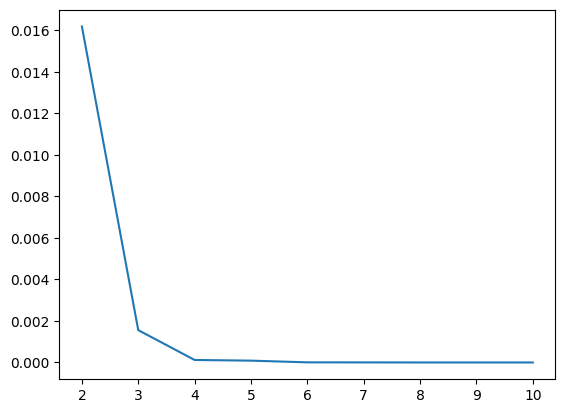

In [33]:
df['lag Varianza'] = df['Varianza Explicada'].shift(1)
df['Ganancia Marginal'] = df['Varianza Explicada'] - df['lag Varianza']

plt.plot(range(1 , 11) ,  df['Ganancia Marginal'][:10])

In [34]:
import pickle as pickle
pickle.dump( pca , open('pca_clase.pca',"wb"))

In [35]:
otro_objeto = pickle.load(open('pca_clase.pca',"rb"))

In [36]:
otro_objeto.components_

array([[ 5.08623202e-03,  2.19657026e-03,  3.50763298e-02,
         5.16826469e-01,  4.23694535e-06,  4.05260047e-05,
         8.19399539e-05,  4.77807775e-05,  7.07804332e-06,
        -2.62155251e-06,  3.13742507e-04, -6.50984008e-05,
         2.23634150e-03,  5.57271669e-02, -8.05646029e-07,
         5.51918197e-06,  8.87094462e-06,  3.27915009e-06,
        -1.24101836e-06, -8.54530832e-08,  7.15473257e-03,
         3.06736622e-03,  4.94576447e-02,  8.52063392e-01,
         6.42005481e-06,  1.01275937e-04,  1.68928625e-04,
         7.36658178e-05,  1.78986262e-05,  1.61356159e-06],
       [ 9.28705650e-03, -2.88160658e-03,  6.27480827e-02,
         8.51823720e-01, -1.48194356e-05, -2.68862249e-06,
         7.51419574e-05,  4.63501038e-05, -2.52430431e-05,
        -1.61197148e-05, -5.38692831e-05,  3.48370414e-04,
         8.19640791e-04,  7.51112451e-03,  1.49438131e-06,
         1.27357957e-05,  2.86921009e-05,  9.36007477e-06,
         1.22647432e-05,  2.89683790e-07, -5.68673345e-

In [37]:
#Creamos dataframe a partir de cada array
df_multi = pd.DataFrame(X, columns = data_names['Nombre de la característica'])
df_uni = pd.DataFrame(y , columns=['Cancer'] )

#concatenamos
df_final = pd.concat([df_multi , df_uni] , axis=1)

<Axes: xlabel='Cancer', ylabel='area'>

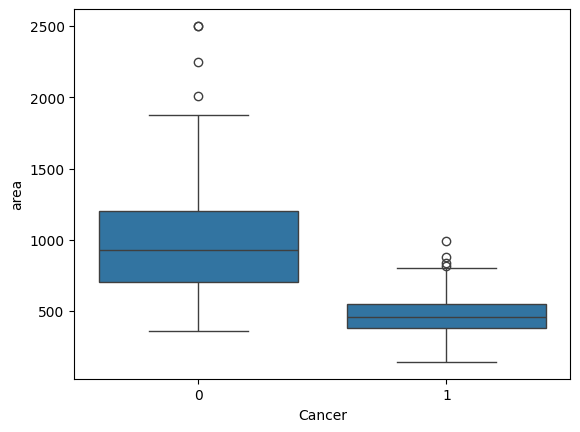

In [38]:
import seaborn as sns
sns.boxplot( x = 'Cancer' , y = 'area' , data=df_final )

<Axes: xlabel='Cancer', ylabel='perimeter_worst'>

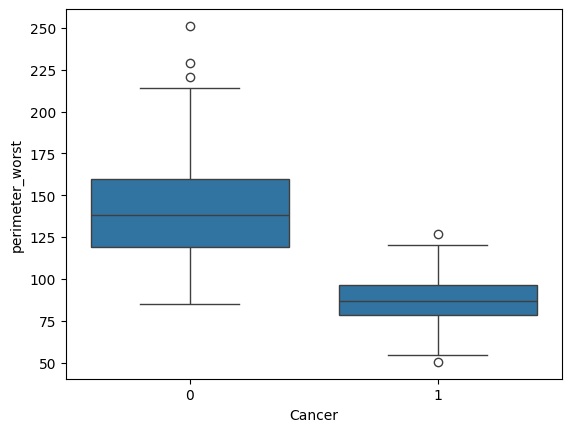

In [39]:
sns.boxplot( x = 'Cancer' , y = 'perimeter_worst' , data=df_final )

In [40]:
otro_objeto_2 = PCA()
otro_objeto_2.fit(df_final)

PCA()

In [41]:
otro_objeto_2.feature_names_in_

array(['radius', 'texture', 'perimeter', 'area', 'smoothness',
       'compactness', 'concavity', 'concave points', 'symmetry',
       'fractal dimension', 'radius_se', 'texture_se', 'perimeter_se',
       'area_se', 'smoothness_se', 'compactness_se', 'concavity_se',
       'concave points_se', 'symmetry_se', 'fractal dimension_se',
       'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst',
       'smoothness_worst', 'compactness_worst', 'concavity_worst',
       'concave points_worst', 'symmetry_worst',
       'fractal dimension_worst', 'Cancer'], dtype=object)

In [42]:
otro_objeto_2.transform(df_final)

array([[ 1.16014274e+03, -2.93917535e+02,  4.85783883e+01, ...,
         1.25556146e-03,  1.99453396e-03,  6.98694809e-04],
       [ 1.26912260e+03,  1.56301938e+01, -3.53943379e+01, ...,
        -1.40254978e-03,  6.11733890e-04, -1.04481116e-03],
       [ 9.95794082e+02,  3.91567229e+01, -1.70992180e+00, ...,
         7.03891493e-05, -7.18480676e-04,  3.92219171e-04],
       ...,
       [ 3.14502046e+02,  4.75534226e+01, -1.04432476e+01, ...,
        -1.32603900e-04,  3.05470796e-04, -2.41610912e-04],
       [ 1.12485829e+03,  3.41292184e+01, -1.97422005e+01, ...,
         1.45834835e-03, -5.58902254e-04,  1.15839814e-03],
       [-7.71527711e+02, -8.86431130e+01,  2.38889805e+01, ...,
        -4.47338326e-03,  1.64210497e-04,  1.48530652e-03]])